In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import ConfusionMatrixDisplay , classification_report 

In [2]:
df = pd.read_csv("Admission_Predict.csv")

In [3]:
df.columns = df.columns.str.strip()
print("COLUMN NAMES :\n",df.columns.tolist())

COLUMN NAMES :
 ['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


In [4]:

X = df[['GRE Score', 'University Rating','CGPA']]
y = df['Chance of Admit']


In [5]:
percentile = np.percentile(y,75)
y_binary = (y > percentile).astype(int)
print(f"\n75 PERCENTILE : {percentile:.2f}")


75 PERCENTILE : 0.83


In [6]:
X_train , X_test , y_train ,y_test = train_test_split(X,y_binary,test_size=0.2,random_state=42)
dt_model = DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=5,min_samples_split =20)
dt_model.fit(X_train,y_train)
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)


FOR TRAINING DATASET : 

               precision    recall  f1-score   support

           0       0.99      0.95      0.97       247
           1       0.84      0.96      0.90        73

    accuracy                           0.95       320
   macro avg       0.92      0.95      0.93       320
weighted avg       0.95      0.95      0.95       320
 



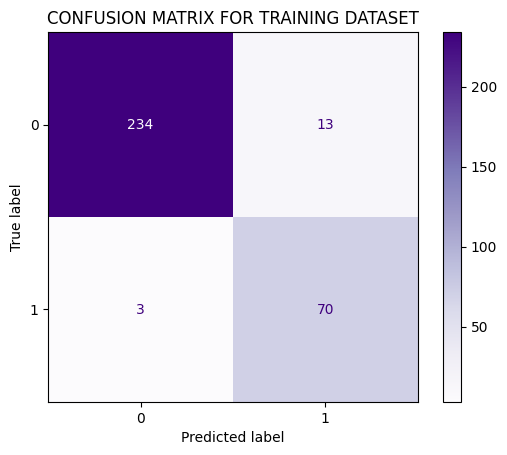

In [7]:
print("\nFOR TRAINING DATASET : \n\n",classification_report(y_train,y_train_pred),"\n")
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,cmap=plt.cm.Purples)
plt.title("CONFUSION MATRIX FOR TRAINING DATASET")
plt.show()


FOR TESTING DATASET : 

               precision    recall  f1-score   support

           0       0.98      0.95      0.96        55
           1       0.89      0.96      0.92        25

    accuracy                           0.95        80
   macro avg       0.94      0.95      0.94        80
weighted avg       0.95      0.95      0.95        80
 



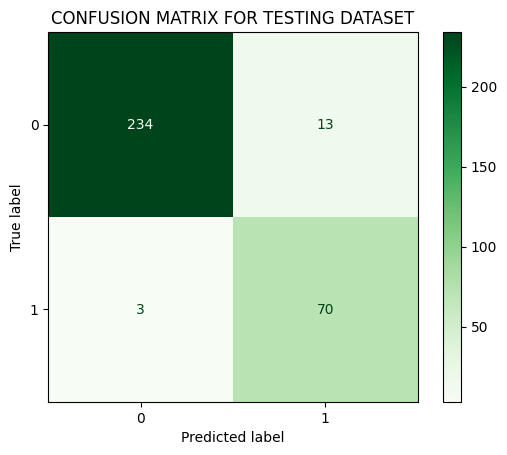

In [8]:
print("\nFOR TESTING DATASET : \n\n",classification_report(y_test,y_test_pred),"\n")
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,cmap=plt.cm.Greens)
plt.title("CONFUSION MATRIX FOR TESTING DATASET")
plt.show()


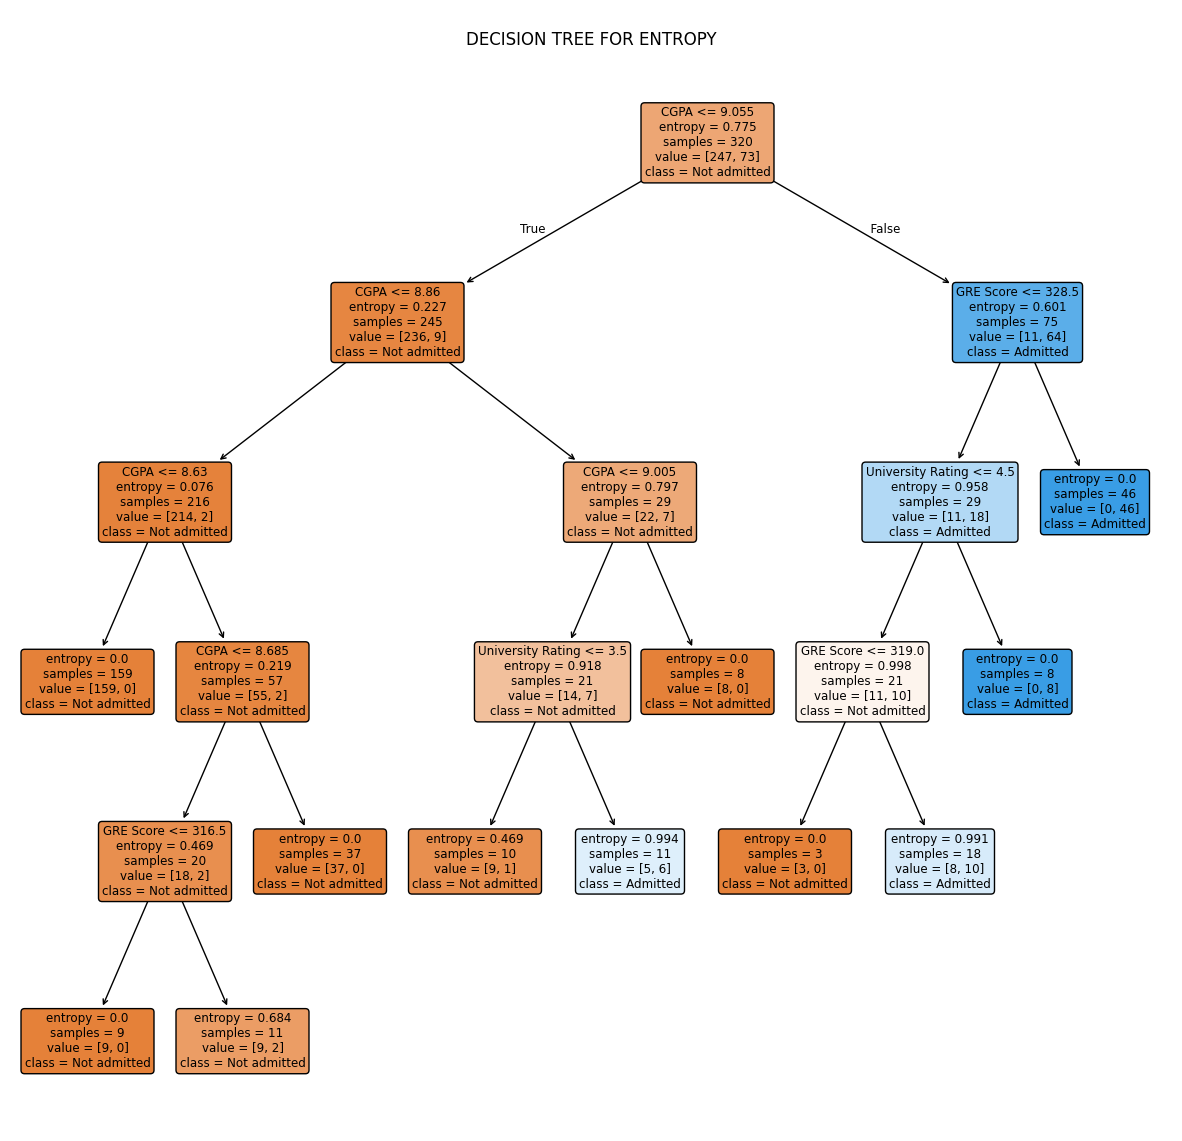

In [9]:
plt.figure(figsize=(15,14))
plot_tree(dt_model,feature_names=X.columns , class_names =['Not admitted','Admitted'],rounded = True , filled = True , impurity = True)
plt.title('\nDECISION TREE FOR ENTROPY')
plt.show()

In [10]:
dt_model = DecisionTreeClassifier(criterion='gini',random_state=42,max_depth=5,min_samples_split =20)
dt_model.fit(X_train,y_train)
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)




FOR TRAINING DATASET : 

               precision    recall  f1-score   support

           0       0.97      0.97      0.97       247
           1       0.90      0.89      0.90        73

    accuracy                           0.95       320
   macro avg       0.94      0.93      0.93       320
weighted avg       0.95      0.95      0.95       320
 



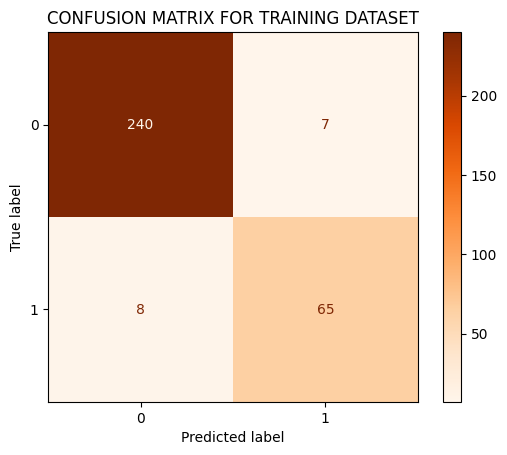

In [11]:

print("\nFOR TRAINING DATASET : \n\n",classification_report(y_train,y_train_pred),"\n")
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,cmap=plt.cm.Oranges)
plt.title("CONFUSION MATRIX FOR TRAINING DATASET")
plt.show()




FOR TESTING DATASET : 

               precision    recall  f1-score   support

           0       0.91      0.95      0.93        55
           1       0.87      0.80      0.83        25

    accuracy                           0.90        80
   macro avg       0.89      0.87      0.88        80
weighted avg       0.90      0.90      0.90        80
 



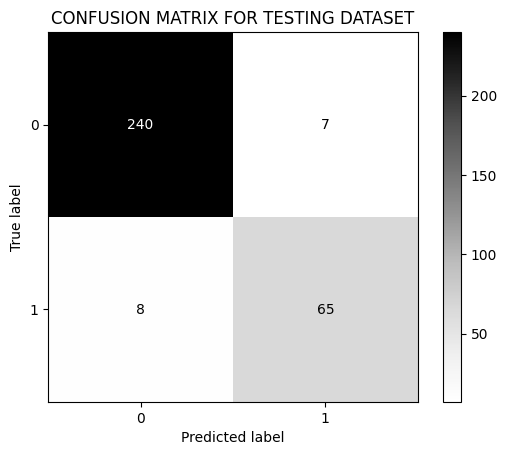

In [12]:
print("\nFOR TESTING DATASET : \n\n",classification_report(y_test,y_test_pred),"\n")
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,cmap=plt.cm.Greys)
plt.title("CONFUSION MATRIX FOR TESTING DATASET")
plt.show()



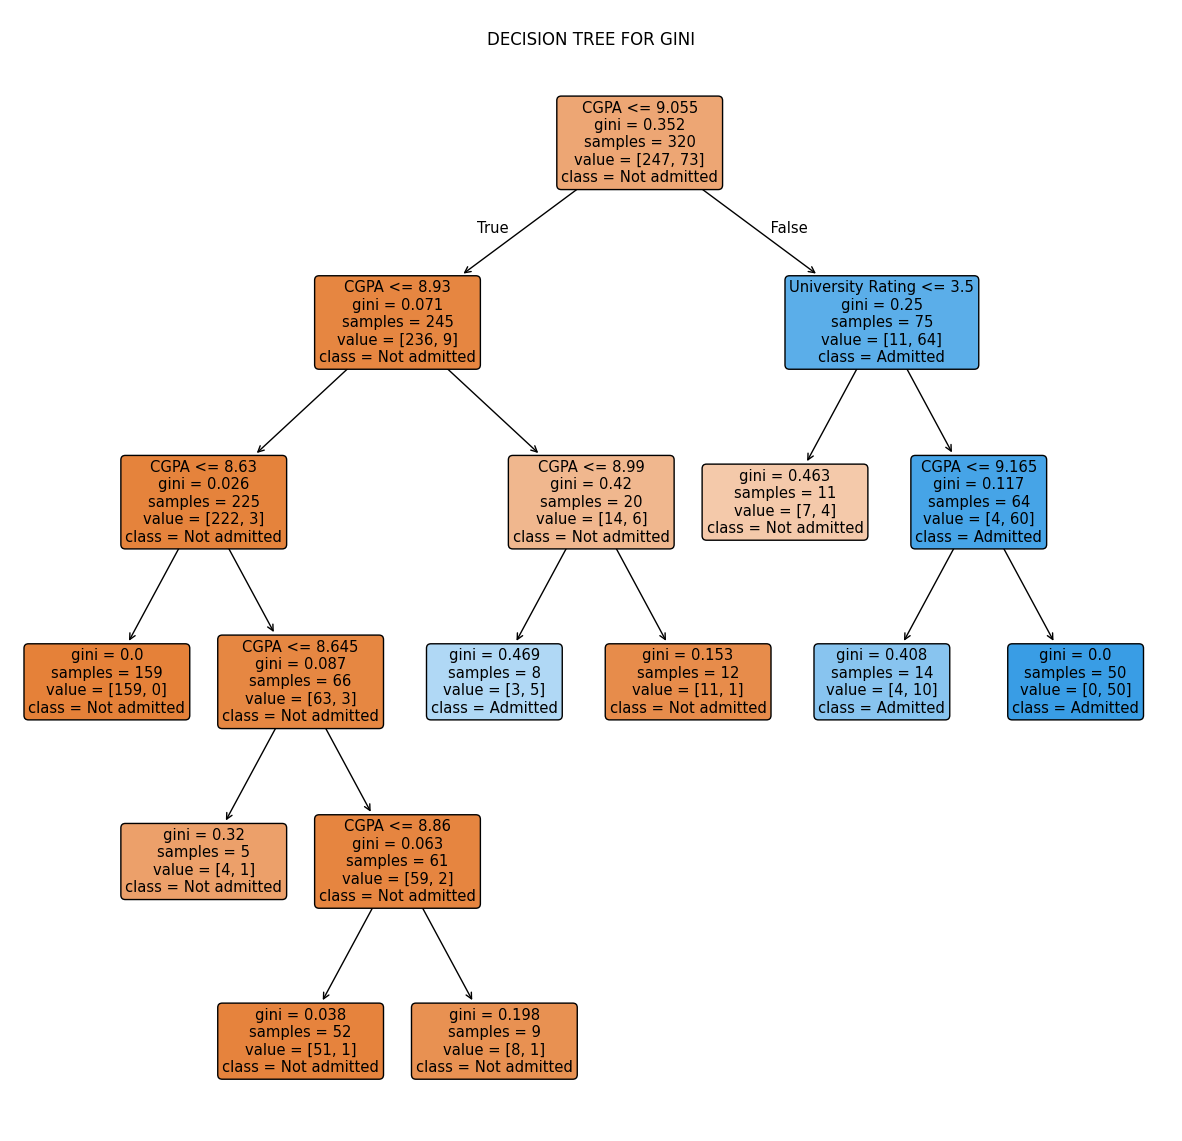

In [13]:
plt.figure(figsize=(15,14))
plot_tree(dt_model,feature_names=X.columns , class_names =['Not admitted','Admitted'],rounded = True , filled = True , impurity = True)
plt.title('\nDECISION TREE FOR GINI')
plt.show()